In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "oasis_longitudinal.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jboysen/mri-and-alzheimers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/Users/ihsanbolum/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_7064/238782329.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:   Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

df = df.copy()


df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [3]:
df["Visit"].describe()

count    373.000000
mean       1.882038
std        0.922843
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
Name: Visit, dtype: float64

In [4]:
features_pca = ["MR Delay", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

df["SES"] = df["SES"].fillna(df["SES"].median())
df["MMSE"] = df["MMSE"].fillna(df["MMSE"].median())

df_visit_1 = df[df["Visit"] == 1].copy()


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_visit_1[features_pca])

scaled_data.shape

(150, 8)

# PCA 
### Visit 1 

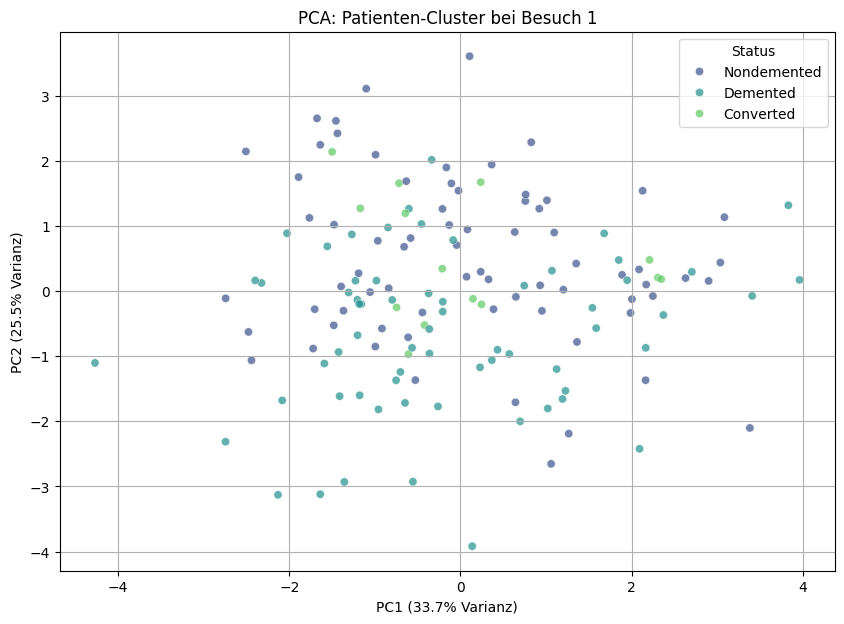

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca =PCA(n_components=2)
pca_res = pca.fit_transform(scaled_data)


df_pca = pd.DataFrame(data = pca_res, columns= ["PC1", "PC2"], index=df_visit_1.index)
df_pca["Status"] = df_visit_1["Group"].values

# visualise

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Status', data=df_pca, palette='viridis', alpha=0.7)
plt.title('PCA: Patienten-Cluster bei Besuch 1')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)')
plt.grid(True)
plt.show()

# PCA 
### Visit 2

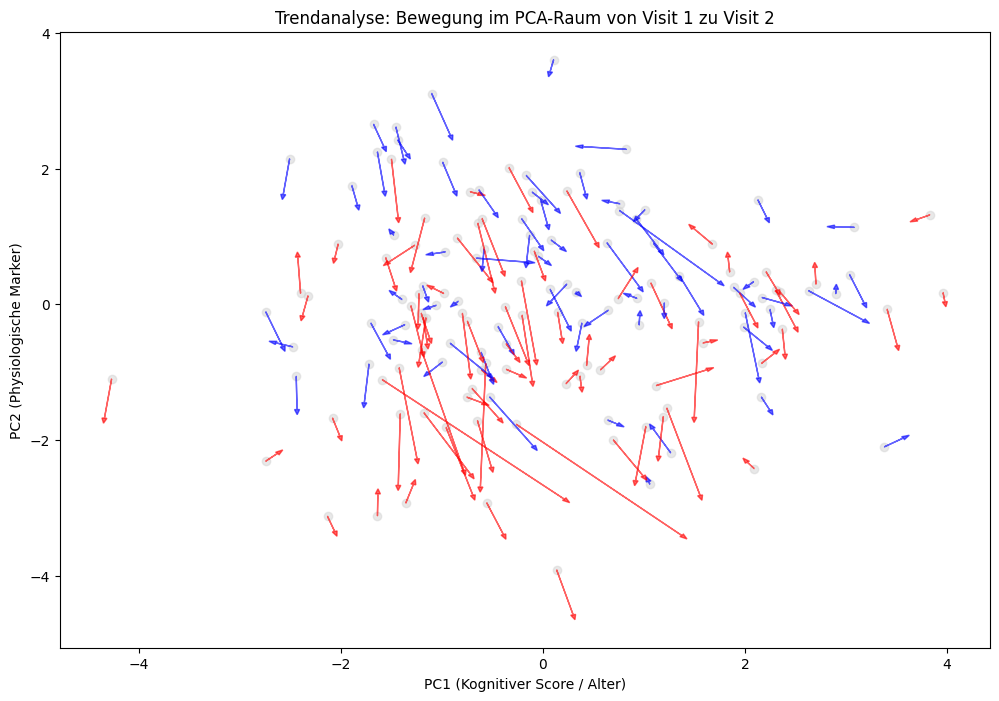

In [6]:
df_visit_2 = df[df["Visit"] == 2].copy()
common_ids = set(df_visit_1["Subject ID"]).intersection(set(df_visit_2["Subject ID"]))
v1_sub = df_visit_1[df_visit_1["Subject ID"].isin(common_ids)].sort_values("Subject ID")
v2_sub = df_visit_2[df_visit_2["Subject ID"].isin(common_ids)].sort_values("Subject ID")

scaled_v1 = scaler.transform(v1_sub[features_pca])
scaled_v2 = scaler.transform(v2_sub[features_pca])

pca_v1 = pca.transform(scaled_v1)
pca_v2 = pca.transform(scaled_v2)

plt.figure(figsize=(12, 8))
plt.scatter(pca_v1[:, 0], pca_v1[:, 1], c='lightgrey', alpha=0.5, label='Start (Visit 1)')

for i in range(len(pca_v1)):
    color = 'blue' if v2_sub.iloc[i]['Group'] == 'Nondemented' else 'red'
    plt.arrow(pca_v1[i, 0], pca_v1[i, 1], 
            pca_v2[i, 0] - pca_v1[i, 0], 
            pca_v2[i, 1] - pca_v1[i, 1], 
            head_width=0.05, color=color, alpha=0.6)
    

plt.title('Trendanalyse: Bewegung im PCA-Raum von Visit 1 zu Visit 2')
plt.xlabel('PC1 (Kognitiver Score / Alter)')
plt.ylabel('PC2 (Physiologische Marker)')
plt.show()


#### "Converted"-Vorhersage (Das Frühwarnsystem)

In [7]:
import pandas as pd 
import numpy as np 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz



df_visit_1
y = df_visit_1["Group"]
df_visit_1_rf = df_visit_1.copy()
mapping_sex = {"M": 0, "F": 1}
mapping_hand = {"R": 0, "L": 1}
df_visit_1_rf["M/F"] =df_visit_1_rf["M/F"].map(mapping_sex)
df_visit_1_rf["Hand"] = df_visit_1_rf["Hand"].map(mapping_hand)

X = df_visit_1_rf[df_visit_1.columns[4:]]
X = X.drop(columns="CDR")



In [8]:
X

,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,eTIV,nWBV,ASF
0,0,0,0,87,14,2.0,27.0,1987,0.696,0.883
2,0,0,0,75,12,2.0,23.0,1678,0.736,1.046
5,0,1,0,88,18,3.0,28.0,1215,0.710,1.444
7,0,0,0,80,12,4.0,28.0,1689,0.712,1.039
10,0,0,0,71,16,2.0,28.0,1357,0.748,1.293
...,...,...,...,...,...,...,...,...,...,...
359,0,0,0,73,12,2.0,23.0,1661,0.698,1.056
361,0,1,0,66,13,2.0,30.0,1495,0.746,1.174
365,0,1,0,72,16,3.0,24.0,1354,0.733,1.296
367,0,0,0,80,16,1.0,28.0,1704,0.711,1.030


In [9]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_predictions = rf.predict(x_test)

acc = accuracy_score(y_test, y_predictions)

acc

0.7

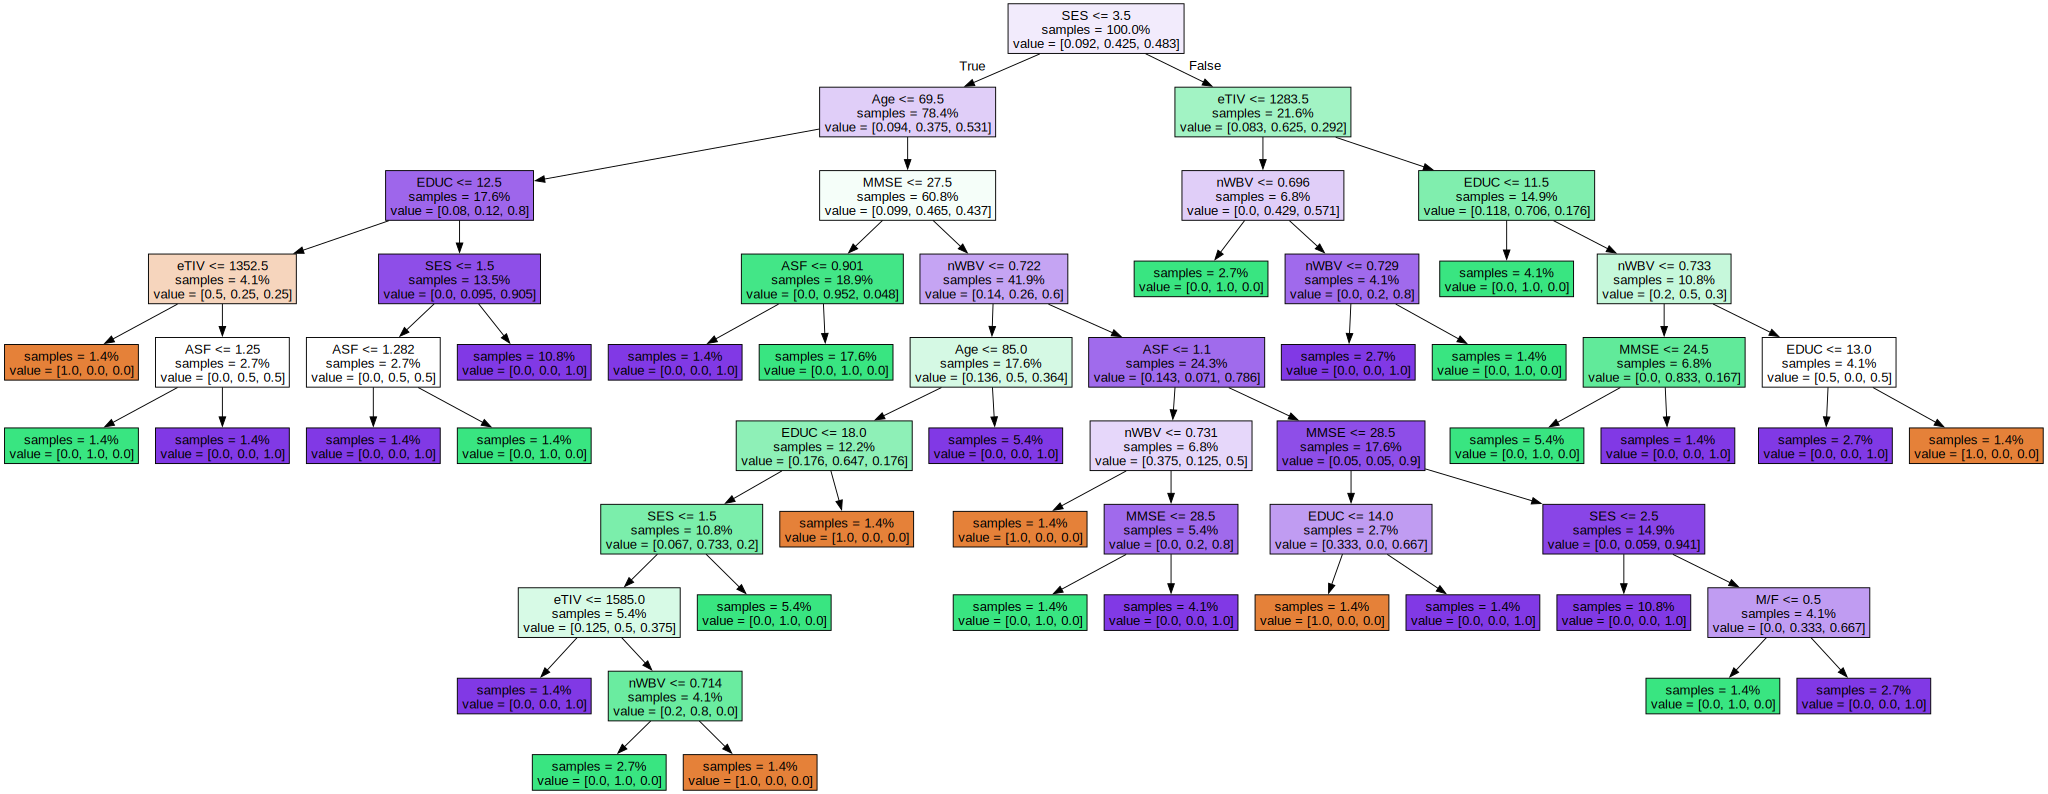

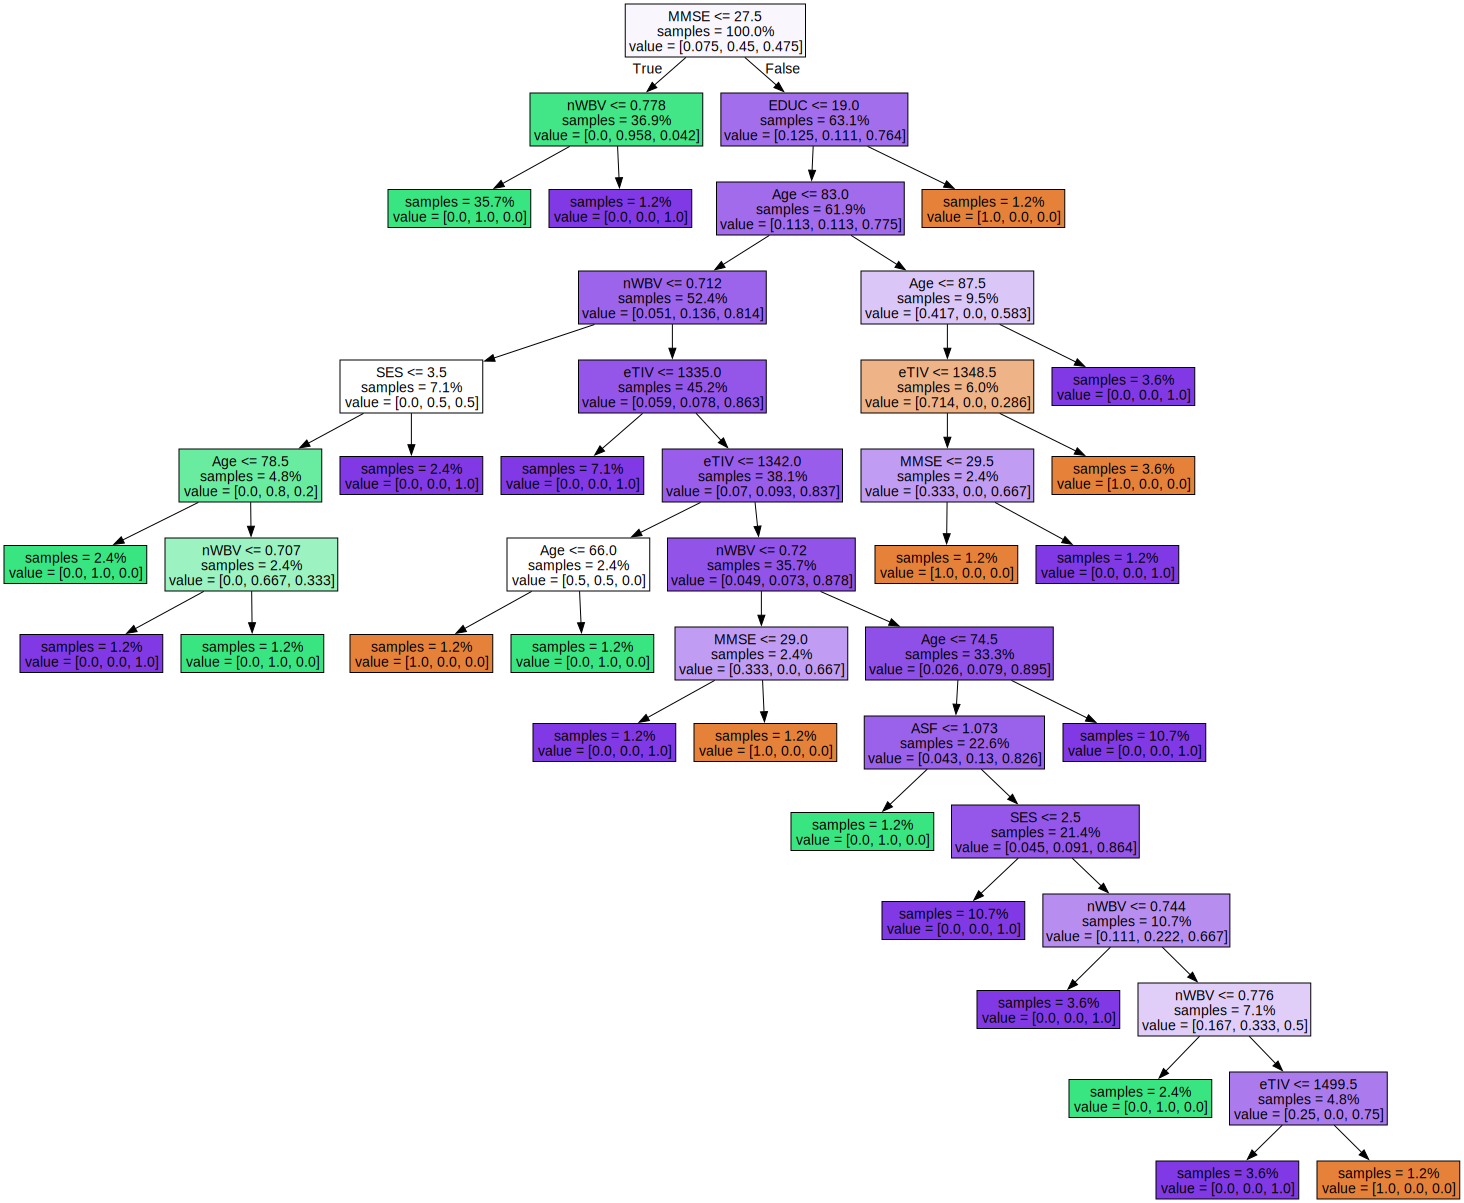

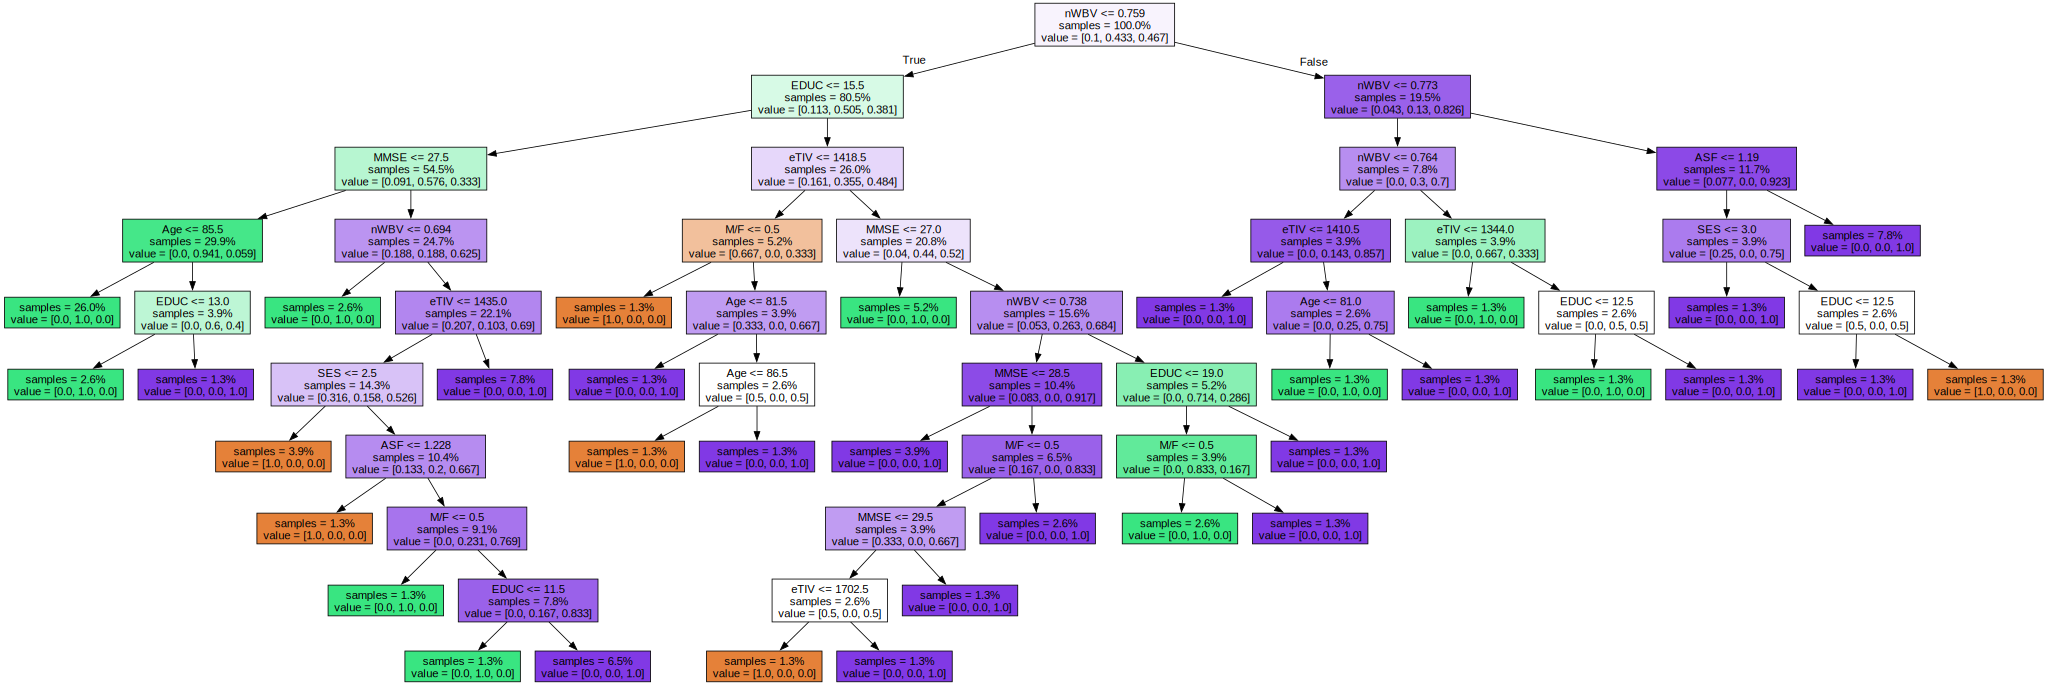

In [10]:
for i in range(3):
    tree = rf.estimators_[i]
    data = export_graphviz(
        tree, 
        feature_names=X_train.columns,
        filled=True,
        max_depth=None,
        impurity=False,
        proportion=True
    )
    graph = graphviz.Source(data)
    display(graph)

# DementiaPredictor (OOP)

In [11]:
class DementiaPreictor:
    def __init__(self,X,y):
        self.X = X
        self.y = y

        self.model = RandomForestClassifier(random_state=42)
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.accuracy = None
        
    def train(self):
        print("Splitting data and traning the model")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        self.X, self.y, test_size = 0.2, random_state = 42, stratify= self.y
        )

        self.model.fit(self.X_train, self.y_train)
        print("Traning done")

    def evaluate(self):
        print("Evaluation")
        predictions = self.model.predict(self.X_test)

        self.accuracy = accuracy_score(self.y_test, predictions)
        print(f"Model Accu.: {self.accuracy * 100:.2f}%")


predictor = DementiaPreictor(X,y)


In [12]:
predictor.train()

predictor.evaluate()

Splitting data and traning the model
Traning done
Evaluation
Model Accu.: 70.00%


oop w child class

In [13]:
from sklearn.linear_model import LogisticRegression


class BaseMedicalPredictor:
    def __init__(self, X,y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.model = None

        self.X_train_scaled = None
        self.X_test_scaled = None
        self.y_train = None
        self.y_test = None

    def prepare_data(self):
        X_train, X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42, stratify=self.y)


        self.X_train_scaled = self.scaler.fit_transform(X_train)
        self.X_test_scaled = self.scaler.fit_transform(X_test)

    def evaluate(self):

        if self.model is None:
            print("Kein Model")
            return
        predictions = self.model.predict(self.X_test_scaled)
        accu = accuracy_score(self.y_test, predictions)
        print(f"model acc.: {accu*100}")

    def train(self):
        pass

class DementiaRandomForest(BaseMedicalPredictor):
    def __init__(self,X,y, trees=100):
        super().__init__(X,y)
        self.model = RandomForestClassifier(n_estimators=trees, random_state=42)
    def train(self):
        print("Train RF")
        self.prepare_data()
        self.model.fit(self.X_train_scaled, self.y_train)


class demetiaLogReg(BaseMedicalPredictor):
    def __init__(self, X,y,c_value=1.0):
        super().__init__(X,y)

        self.model = LogisticRegression(C=c_value, random_state=42)

    def train(self):
        print("Train Logistische Reg")
        self.prepare_data()
        self.model.fit(self.X_train_scaled, self.y_train)

In [14]:
rf_modell = DementiaRandomForest(X, y, trees=100)
rf_modell.train()
rf_modell.evaluate()


log_modell = demetiaLogReg(X, y, c_value=0.5)
log_modell.train()
log_modell.evaluate()

Train RF
model acc.: 66.66666666666666
Train Logistische Reg
model acc.: 73.33333333333333


# PCA Trajectory Predictor

In [15]:
df

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [16]:
patience = df.copy() 
len(patience["Visit"] == 1)

373

In [17]:
len(patience[patience["Visit"] == 4])

15

In [18]:
map_dem = {
    "Nondemented": 0,
    "Demented": 1,
    "Converted": 1
}

map_sex = {
    "M": 1,
    "F": 0
}

map_hand = {
    "R": 0,
    "L":1
}

patience["Group"] = patience["Group"].map(map_dem)
patience["Hand"] = patience["Hand"].map(map_hand)
patience["M/F"] = patience["M/F"].map(map_sex)

patience

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,1,3,1895,1,0,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,1,3,2297,1,0,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,0,2,763,0,0,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [19]:

ids_1 = patience[patience["Visit"] == 1]["Subject ID"]
ids_2 = patience[patience["Visit"] == 2]["Subject ID"]



ids_pool_1_2 = set(ids_1).intersection(set(ids_2))


patience_1_2 = patience[patience["Subject ID"].isin(ids_pool_1_2)]




In [20]:
patience_1_2 = patience_1_2[patience_1_2["Visit"].isin([1,2])]

In [21]:
patience_1_2

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,OAS2_0184,OAS2_0184_MR2,1,2,553,0,0,73,16,3.0,21.0,1.0,1351,0.708,1.299
367,OAS2_0185,OAS2_0185_MR1,1,1,0,1,0,80,16,1.0,28.0,0.5,1704,0.711,1.030
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331


In [22]:
patience_1_2["Visit"].unique()

array([1, 2])

In [23]:
unique_ids = patience_1_2["Subject ID"].unique()

In [24]:
unique_ids

array(['OAS2_0001', 'OAS2_0002', 'OAS2_0004', 'OAS2_0005', 'OAS2_0008',
       'OAS2_0009', 'OAS2_0010', 'OAS2_0012', 'OAS2_0013', 'OAS2_0014',
       'OAS2_0016', 'OAS2_0020', 'OAS2_0021', 'OAS2_0022', 'OAS2_0023',
       'OAS2_0026', 'OAS2_0027', 'OAS2_0028', 'OAS2_0029', 'OAS2_0030',
       'OAS2_0031', 'OAS2_0032', 'OAS2_0034', 'OAS2_0035', 'OAS2_0037',
       'OAS2_0039', 'OAS2_0040', 'OAS2_0041', 'OAS2_0042', 'OAS2_0043',
       'OAS2_0044', 'OAS2_0045', 'OAS2_0046', 'OAS2_0047', 'OAS2_0048',
       'OAS2_0049', 'OAS2_0050', 'OAS2_0051', 'OAS2_0052', 'OAS2_0053',
       'OAS2_0054', 'OAS2_0055', 'OAS2_0056', 'OAS2_0057', 'OAS2_0058',
       'OAS2_0060', 'OAS2_0061', 'OAS2_0062', 'OAS2_0063', 'OAS2_0064',
       'OAS2_0066', 'OAS2_0067', 'OAS2_0068', 'OAS2_0069', 'OAS2_0070',
       'OAS2_0071', 'OAS2_0073', 'OAS2_0075', 'OAS2_0076', 'OAS2_0077',
       'OAS2_0078', 'OAS2_0079', 'OAS2_0080', 'OAS2_0081', 'OAS2_0085',
       'OAS2_0086', 'OAS2_0087', 'OAS2_0088', 'OAS2_0090', 'OAS2

In [25]:
df_train_id, df_test_id = train_test_split(unique_ids, test_size=0.2, random_state=42)

df_train = patience_1_2[patience_1_2["Subject ID"].isin(df_train_id)]
df_test = patience_1_2[patience_1_2["Subject ID"].isin(df_test_id)]

In [26]:
df_train

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,OAS2_0184,OAS2_0184_MR2,1,2,553,0,0,73,16,3.0,21.0,1.0,1351,0.708,1.299
367,OAS2_0185,OAS2_0185_MR1,1,1,0,1,0,80,16,1.0,28.0,0.5,1704,0.711,1.030
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331


In [27]:
df_test

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
13,OAS2_0008,OAS2_0008_MR1,0,1,0,0,0,93,14,2.0,30.0,0.0,1272,0.698,1.380
14,OAS2_0008,OAS2_0008_MR2,0,2,742,0,0,95,14,2.0,29.0,0.0,1257,0.703,1.396
25,OAS2_0014,OAS2_0014_MR1,1,1,0,1,0,76,16,3.0,21.0,0.5,1602,0.697,1.096
26,OAS2_0014,OAS2_0014_MR2,1,2,504,1,0,77,16,3.0,16.0,1.0,1590,0.696,1.104
36,OAS2_0020,OAS2_0020_MR1,1,1,0,1,0,80,20,1.0,29.0,0.0,1587,0.693,1.106
37,OAS2_0020,OAS2_0020_MR2,1,2,756,1,0,82,20,1.0,28.0,0.5,1606,0.677,1.093
39,OAS2_0021,OAS2_0021_MR1,1,1,0,1,0,72,20,1.0,26.0,0.5,1911,0.719,0.919
40,OAS2_0021,OAS2_0021_MR2,1,2,1164,1,0,76,20,1.0,25.0,0.5,1926,0.736,0.911
53,OAS2_0029,OAS2_0029_MR1,0,1,0,0,0,77,12,4.0,29.0,0.0,1377,0.734,1.275
54,OAS2_0029,OAS2_0029_MR2,0,2,1099,0,0,80,12,4.0,30.0,0.0,1390,0.735,1.263


In [28]:
scale = StandardScaler()
pca = PCA(n_components=2)
def scale_data_PCA(df, n):

    pca_featres = ["MR Delay"	,"M/F"	,"Hand"	,"Age"	,"EDUC"	,"SES"	,"MMSE"	,"CDR"	,"eTIV"	,"nWBV","ASF"]

    if n == 1: #train
        

        pca_scale = scale.fit_transform(df[pca_featres])
        pca_res = pca.fit_transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)
        df = pd.concat([df, pca_res], axis=1)
        return df

    if n == 2 : #test

        pca_scale = scale.transform(df[pca_featres])
        pca_res = pca.transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)



        df = pd.concat([df, pca_res], axis=1)
        return df
    return

In [29]:
df_train = scale_data_PCA(df_train,1)
df_test = scale_data_PCA(df_test,2)

In [30]:
features_lstm = ["MR Delay",	"Age"	,"EDUC"	,"SES"	,"MMSE"	,"CDR"	,"eTIV"	,"nWBV"	,"ASF"]
import joblib
df_train[features_lstm] = scaler.fit_transform(df_train[features_lstm])
df_test[features_lstm] = scaler.transform(df_test[features_lstm])
joblib.dump(scaler, "alz_scaler.save")

df_test

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,PC1,PC2
13,OAS2_0008,OAS2_0008_MR1,0,1,-0.894294,0,0,2.250713,-0.214579,-0.392626,0.821900,-0.853856,-1.186405,-0.829575,1.270275,-1.534843,0.693786
14,OAS2_0008,OAS2_0008_MR2,0,2,1.008322,0,0,2.522953,-0.214579,-0.392626,0.537634,-0.853856,-1.270977,-0.693385,1.383533,-1.541676,0.486864
25,OAS2_0014,OAS2_0014_MR1,1,1,-0.894294,1,0,-0.063325,0.490465,0.548040,-1.736494,0.538959,0.674171,-0.856813,-0.740055,1.448265,-1.687169
26,OAS2_0014,OAS2_0014_MR2,1,2,0.398049,1,0,0.072795,0.490465,0.548040,-3.157824,1.931773,0.606514,-0.884051,-0.683426,1.582184,-3.236403
36,OAS2_0020,OAS2_0020_MR1,1,1,-0.894294,1,0,0.481154,1.900553,-1.333292,0.537634,-0.853856,0.589599,-0.965765,-0.669269,2.169954,1.436519
37,OAS2_0020,OAS2_0020_MR2,1,2,1.044220,1,0,0.753394,1.900553,-1.333292,0.253368,0.538959,0.696723,-1.401573,-0.761291,2.591374,0.326378
39,OAS2_0021,OAS2_0021_MR1,1,1,-0.894294,1,0,-0.607805,1.900553,-1.333292,-0.315164,0.538959,2.416347,-0.257577,-1.992972,3.841351,0.542028
40,OAS2_0021,OAS2_0021_MR2,1,2,2.090403,1,0,-0.063325,1.900553,-1.333292,-0.599430,0.538959,2.500918,0.205469,-2.049601,4.034596,0.371961
53,OAS2_0029,OAS2_0029_MR1,0,1,-0.894294,0,0,0.072795,-0.919623,1.488706,0.537634,-0.853856,-0.594404,0.150993,0.527019,-1.788131,0.048114
54,OAS2_0029,OAS2_0029_MR2,0,2,1.923732,0,0,0.481154,-0.919623,1.488706,0.821900,-0.853856,-0.521108,0.178231,0.442076,-1.523842,0.058999


In [31]:
def reshape_dim(df, features, n_visit):
    n_id = df["Subject ID"].nunique()
    n_features = len(features)
    print(n_id)

    df = df.sort_values(by=["Subject ID", "Visit"] )

    df_3d = df[features].values.reshape(n_id, n_visit, n_features)

    

    return df_3d

In [32]:
df_test.shape

(58, 17)

In [33]:
df_train.shape

(230, 17)

In [34]:
df_test_3d = reshape_dim(df_test, features_lstm, 2)
df_train_3d = reshape_dim(df_train, features_lstm, 2)

print(df_test_3d.shape, df_train_3d.shape)

29
115
(29, 2, 9) (115, 2, 9)


In [35]:
X_train_2v = df_train_3d[:, :2, :]
X_test_2v = df_test_3d[:, :2, :]

X_test_2v.shape, X_train_2v.shape

X_train_2v = np.asarray(X_train_2v).astype('float32')
X_test_2v = np.asarray(X_test_2v).astype('float32')

In [124]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout


inputs = Input(shape=(2, 9), name='input_layer')
lstm_out= LSTM(units=2, activation="tanh")(inputs)

dropout_ra = Dropout(0.35)(lstm_out)

pca_output = Dense(units=2, activation="linear", name="pca_prediction")(dropout_ra)
group_output = Dense(units=1, activation="sigmoid", name="group_prediction")(dropout_ra)

model = Model(inputs=inputs, outputs=[pca_output, group_output])

model.compile(
    optimizer="adam",
    loss={
        "pca_prediction": "mse",
        "group_prediction": "binary_crossentropy"
    },
    metrics={
        'pca_prediction': 'mae',                 
        'group_prediction': 'accuracy'
    },
    loss_weights={
       'pca_prediction': 1.0, 
        'group_prediction': 0.8 
    }
)




In [125]:
df_train

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,PC1,PC2
0,OAS2_0001,OAS2_0001_MR1,0,1,-0.894294,1,0,1.433994,-0.214579,-0.392626,-0.030898,-0.853856,2.844843,-0.884051,-2.247802,3.534637,-0.191572
1,OAS2_0001,OAS2_0001_MR2,0,2,0.277533,1,0,1.570114,-0.214579,-0.392626,0.821900,-0.853856,2.940691,-1.292621,-2.297352,3.759139,0.073844
2,OAS2_0002,OAS2_0002_MR1,1,1,-0.894294,1,0,-0.199445,-0.919623,-0.392626,-1.167962,0.538959,1.102667,0.205469,-1.093986,1.581047,-1.259370
3,OAS2_0002,OAS2_0002_MR2,1,2,0.541643,1,0,-0.063325,-0.919623,-0.392626,0.253368,0.538959,1.440954,-0.421005,-1.348817,2.104380,-0.775838
5,OAS2_0004,OAS2_0004_MR1,0,1,-0.894294,0,0,1.570114,1.195509,0.548040,0.253368,-0.853856,-1.507778,-0.502719,1.723307,-1.968990,0.798038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,OAS2_0184,OAS2_0184_MR2,1,2,0.523693,0,0,-0.471685,0.490465,0.548040,-1.736494,1.931773,-0.740995,-0.557195,0.696906,-0.921010,-1.926131
367,OAS2_0185,OAS2_0185_MR1,1,1,-0.894294,1,0,0.481154,0.490465,-1.333292,0.253368,0.538959,1.249258,-0.475481,-1.207244,2.486451,0.145961
368,OAS2_0185,OAS2_0185_MR2,1,2,1.264739,1,0,0.753394,0.490465,-1.333292,0.253368,0.538959,1.187239,-0.938527,-1.157694,2.656314,-0.119429
370,OAS2_0186,OAS2_0186_MR1,0,1,-0.894294,0,0,-2.105124,-0.567101,-0.392626,0.821900,-0.853856,-0.921414,1.975940,0.923422,-2.012342,1.828672


In [126]:

y_train_pca = df_train.groupby("Subject ID")[["PC1", "PC2"]].last()
y_train_group = df_train.groupby("Subject ID")["Group"].first()

y_test_pca = df_test.groupby("Subject ID")[["PC1", "PC2"]].last()
y_test_group = df_test.groupby("Subject ID")["Group"].first()

y_train_dict = {
    'pca_prediction': y_train_pca,
    'group_prediction': y_train_group
}

y_test_dict = {
    'pca_prediction': y_test_pca,
    'group_prediction': y_test_group
}


y_train_dict['pca_prediction'] = np.asarray(y_train_dict['pca_prediction']).astype('float32')
y_train_dict['group_prediction'] = np.asarray(y_train_dict['group_prediction']).astype('float32')

y_test_dict['pca_prediction'] = np.asarray(y_test_dict['pca_prediction']).astype('float32')
y_test_dict['group_prediction'] = np.asarray(y_test_dict['group_prediction']).astype('float32')
history = model.fit(
    X_train_2v,           
    y_train_dict,         
    epochs=140,
    batch_size=8,
    validation_data=(X_test_2v, y_test_dict),
    verbose=1,

)


Epoch 1/140
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - group_prediction_accuracy: 0.5602 - group_prediction_loss: 0.6848 - loss: 2.9574 - pca_prediction_loss: 2.4100 - pca_prediction_mae: 1.2303 - val_group_prediction_accuracy: 0.4483 - val_group_prediction_loss: 0.7023 - val_loss: 3.3071 - val_pca_prediction_loss: 2.7143 - val_pca_prediction_mae: 1.2352
Epoch 2/140
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.5223 - group_prediction_loss: 0.6887 - loss: 3.2651 - pca_prediction_loss: 2.7027 - pca_prediction_mae: 1.3183 - val_group_prediction_accuracy: 0.5172 - val_group_prediction_loss: 0.7004 - val_loss: 3.2797 - val_pca_prediction_loss: 2.6885 - val_pca_prediction_mae: 1.2285
Epoch 3/140
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.5895 - group_prediction_loss: 0.6854 - loss: 3.2558 - pca_prediction_loss: 2.7034 - pca_prediction_mae: 1.3254 - val_group_prediction_accuracy: 0.5172 - val_group_prediction_loss: 0.6985 - val_loss: 3.2540 -

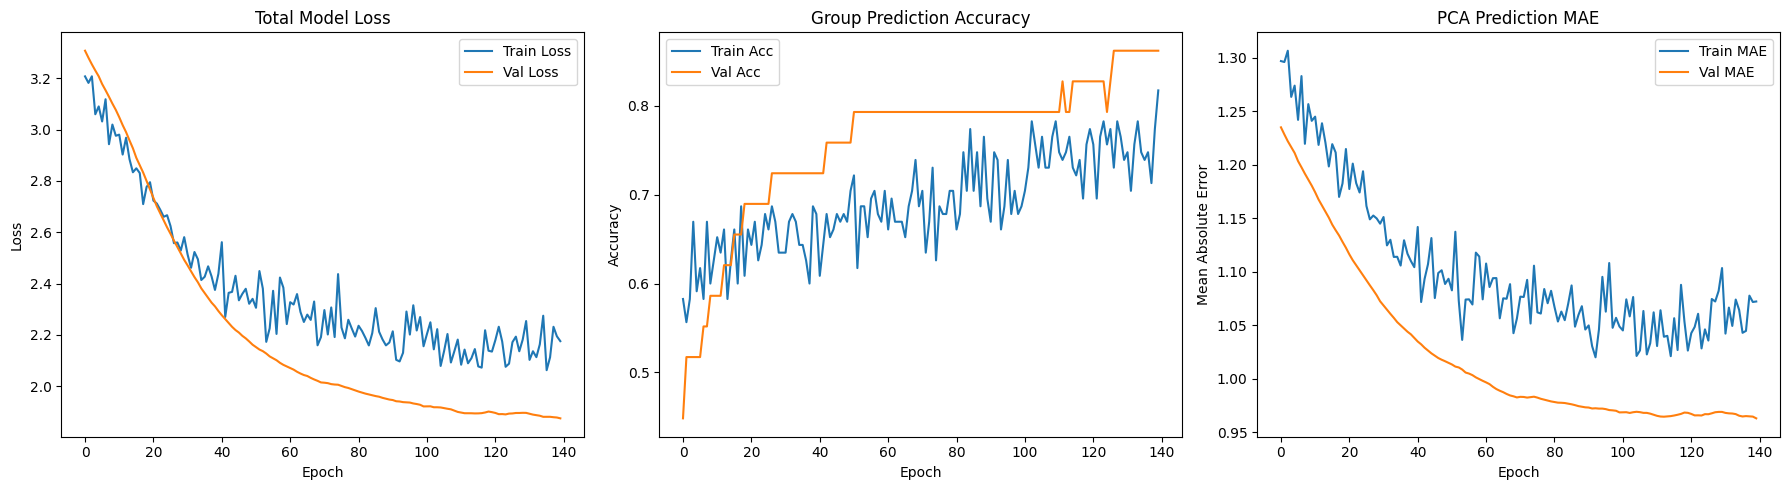

In [127]:
import matplotlib.pyplot as plt

def plot_history(history):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Total Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['group_prediction_accuracy'], label='Train Acc')
    ax2.plot(history.history['val_group_prediction_accuracy'], label='Val Acc')
    ax2.set_title('Group Prediction Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()


    ax3.plot(history.history['pca_prediction_mae'], label='Train MAE')
    ax3.plot(history.history['val_pca_prediction_mae'], label='Val MAE')
    ax3.set_title('PCA Prediction MAE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Mean Absolute Error')
    ax3.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

In [128]:
model.save('pca_trajectory_model.keras')

# Visit 4 Prediction

In [129]:
df["Visit"].unique()

array([1, 2, 3, 4, 5])

In [130]:
df_v4 = df[df["Visit"] == 4]["Subject ID"]
df_v3 = df[df["Visit"] ==3]["Subject ID"]

ids_v_3_4 = set(df_v3).intersection(set(df_v4))

df_visit3_4 = df[df["Subject ID"].isin(ids_v_3_4)].copy()
df_visit3_4 = df_visit3_4[df_visit3_4["Visit"].isin([3,4])]

In [131]:

len(ids_v_3_4)

15

In [132]:
df_visit3_4

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
11,OAS2_0007,OAS2_0007_MR3,Demented,3,518,M,R,73,16,2.0,27.0,1.0,1365,0.727,1.286
12,OAS2_0007,OAS2_0007_MR4,Demented,4,1281,M,R,75,16,2.0,27.0,1.0,1372,0.710,1.279
30,OAS2_0017,OAS2_0017_MR3,Nondemented,3,617,M,R,81,12,3.0,27.0,0.5,1814,0.759,0.968
31,OAS2_0017,OAS2_0017_MR4,Nondemented,4,1861,M,R,85,12,3.0,30.0,0.0,1820,0.755,0.964
34,OAS2_0018,OAS2_0018_MR3,Converted,3,489,F,R,88,14,1.0,29.0,0.0,1398,0.713,1.255
35,OAS2_0018,OAS2_0018_MR4,Converted,4,1933,F,R,92,14,1.0,27.0,0.5,1423,0.696,1.234
49,OAS2_0027,OAS2_0027_MR3,Nondemented,3,1234,F,R,73,12,3.0,30.0,0.0,1358,0.775,1.293
50,OAS2_0027,OAS2_0027_MR4,Nondemented,4,1779,F,R,74,12,3.0,30.0,0.0,1353,0.772,1.297
64,OAS2_0034,OAS2_0034_MR3,Nondemented,3,1287,F,R,82,16,1.0,30.0,0.0,1460,0.695,1.202
65,OAS2_0034,OAS2_0034_MR4,Nondemented,4,1884,F,R,84,16,1.0,30.0,0.0,1453,0.684,1.208


In [133]:
def pca_results_plot(df, visit):
    scaler = StandardScaler()
    pca = PCA(n_components=2)
    df = df.copy()
    map_dem = {
    "Nondemented": 0,
    "Demented": 1,
    "Converted": 1
    }

    map_sex = {
    "M": 1,
    "F": 0
    }

    map_hand = {
    "R": 0,
    "L":1
    }

    df["Group"] = df["Group"].map(map_dem)
    df["Hand"] = df["Hand"].map(map_hand)
    df["M/F"] = df["M/F"].map(map_sex)
    pca_featres = ["MR Delay"	,"M/F"	,"Hand"	,"Age"	,"EDUC"	,"SES"	,"MMSE"	,"eTIV"	,"nWBV","ASF"]
    df = df[df["Visit"] == visit].copy()

    scale_data = scaler.fit_transform(df[pca_featres])
    pca_res = pca.fit_transform(scale_data)

    pca_df = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)

    plt.figure(figsize=(8, 6))


    for i, txt in enumerate(pca_df.index):
        # 1. Get the coordinates for just this one point
        x = pca_df["PC1"].iloc[i]
        y = pca_df["PC2"].iloc[i]
        
        # 2. Check the "Group" value in the original df using the index 'txt'
        group_val = df.loc[txt, "Group"]
        
        # 3. Assign color based on that group value
        point_color = 'red' if group_val == 1 else 'green'
        
        # 4. Plot only this specific point
        plt.scatter(x, y, color=point_color, alpha=0.7)
        
        # Your original annotation code
        plt.annotate(txt, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=7)
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')


    plt.grid(True, alpha=0.3)
    return plt.show()


In [134]:
def pca_results_plot(df, visit):
    scaler = StandardScaler()
    pca = PCA(n_components=2)
    df = df.copy()
    
    map_dem = {"Nondemented": 0, "Demented": 1, "Converted": 1}
    map_sex = {"M": 1, "F": 0}
    map_hand = {"R": 0, "L":1}

    df["Group"] = df["Group"].map(map_dem)
    df["Hand"] = df["Hand"].map(map_hand)
    df["M/F"] = df["M/F"].map(map_sex)
    
    pca_featres = ["MR Delay", "M/F", "Hand", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
    
    # Filtern nach Visit
    df = df[df["Visit"] == visit].copy()
    
    # (Optional, aber empfohlen: Fehlende Werte auffüllen, da PCA sonst Fehler werfen kann)
    df["SES"] = df["SES"].fillna(df["SES"].median())
    df["MMSE"] = df["MMSE"].fillna(df["MMSE"].median())

    scale_data = scaler.fit_transform(df[pca_featres])
    pca_res = pca.fit_transform(scale_data)

    # Wir erstellen den DataFrame, aber brauchen den Index nicht mehr zwingend für die Schleife
    pca_df = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"])

    plt.figure(figsize=(10, 7))

    # Wir iterieren über die Länge des DataFrames
    for i in range(len(pca_df)):
        # 1. Koordinaten holen
        x = pca_df["PC1"].iloc[i]
        y = pca_df["PC2"].iloc[i]
        
        # 2. Gruppe über die Position holen (iloc)
        group_val = df["Group"].iloc[i]
        point_color = 'red' if group_val == 1 else 'green'
        
        # 3. Subject ID über die Position holen und kürzen
        full_id = df["Subject ID"].iloc[i]
        try:
            # Macht aus 'OAS2_0007' -> '7'
            short_id = str(int(str(full_id).split('_')[1]))
        except:
            short_id = str(full_id)
        
        # 4. Plotten und Beschriften
        plt.scatter(x, y, color=point_color, alpha=0.7, s=50)
        plt.annotate(short_id, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=9)
        
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.title(f'PCA - Wahre Daten für Visit {visit}')
    plt.grid(True, alpha=0.3)
    plt.show()

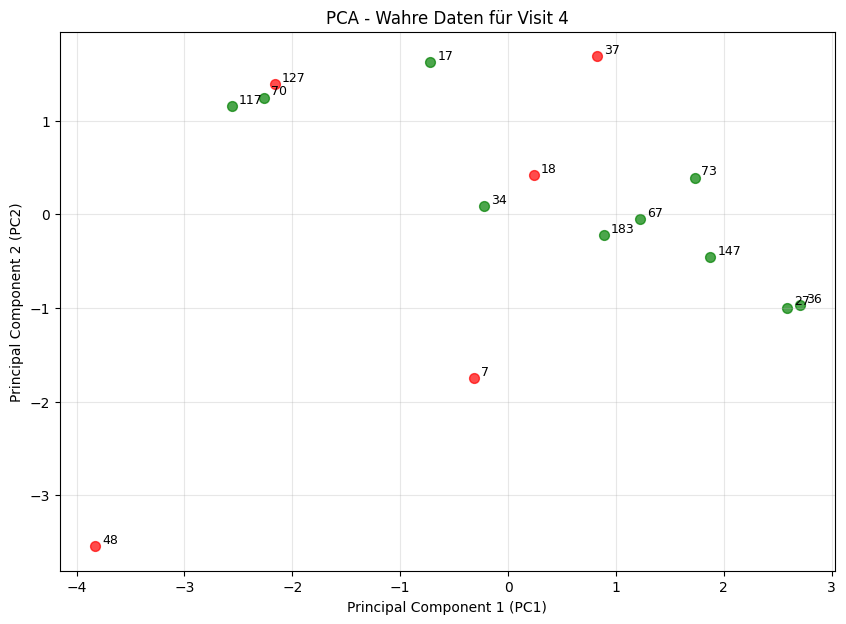

In [135]:
pca_results_plot(df,4)

In [136]:
model_alzeh = tf.keras.models.load_model("pca_trajectory_model.keras")

In [137]:
def prep_data_predict(df):
    scaler = joblib.load("alz_scaler.save")
    df = df.copy()
    df["Group"] = df["Group"].map(map_dem)

    df["Hand"] = df["Hand"].map(map_hand)

    df["M/F"] = df["M/F"].map(map_sex)

    features_lstm = ["MR Delay",	"Age"	,"EDUC"	,"SES"	,"MMSE"	,"CDR"	,"eTIV"	,"nWBV"	,"ASF"]
    df[features_lstm] = scaler.transform(df[features_lstm])
    print(df[features_lstm].shape)
#    model = tf.keras.models.load_model("pca_trajectory_model.keras")
 #   #input_data = df[features_lstm].reshape((1,9,None))
  #  predictions = model.predict(df[features_lstm])
    return df[features_lstm]#predictions


In [138]:
#df_visit3_4_reshaped = df_visit3_4.values.reshape(-1,2,9) 
df_visit3_4_clean = prep_data_predict(df_visit3_4)

df_visit3_4_reshaped = df_visit3_4_clean.values.reshape(-1,2,9)


(30, 9)


In [139]:
model = tf.keras.models.load_model("pca_trajectory_model.keras")
predictions = model.predict(df_visit3_4_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [140]:
predictions[1]

array([[0.6963019 ],
       [0.7140975 ],
       [0.6589058 ],
       [0.24320948],
       [0.43545815],
       [0.2520685 ],
       [0.77188706],
       [0.9054811 ],
       [0.5718799 ],
       [0.5872686 ],
       [0.3805763 ],
       [0.58742577],
       [0.7417486 ],
       [0.26171908],
       [0.4793041 ]], dtype=float32)

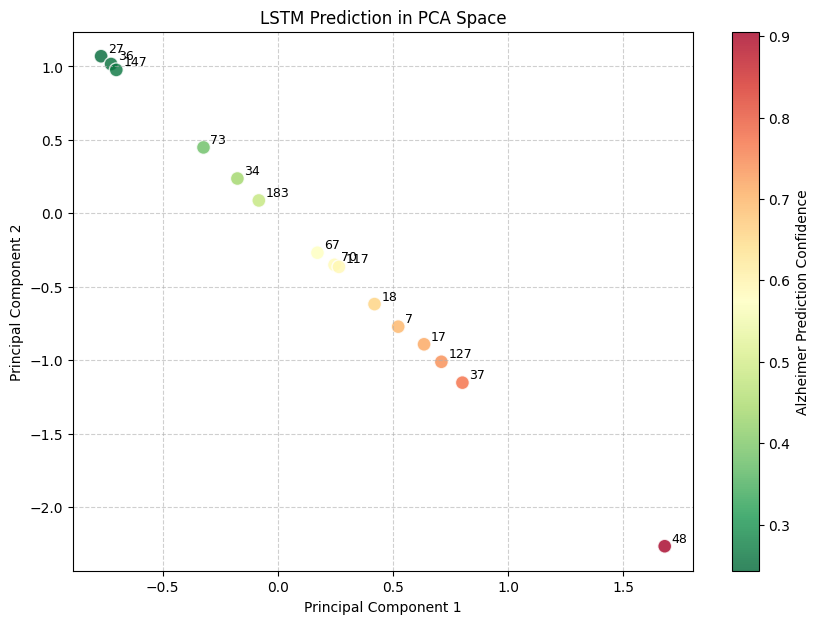

In [141]:
import matplotlib.pyplot as plt
import numpy as np

pca_coords = predictions[0]
confidence = predictions[1]

# Get unique Subject IDs in the same order used for reshaping
subject_ids = df_visit3_4.sort_values(by=["Subject ID", "Visit"])["Subject ID"].unique()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                      c=confidence.flatten(), 
                      cmap='RdYlGn_r', 
                      s=100,           
                      edgecolors='w',
                      alpha=0.8) 

cbar = plt.colorbar(scatter)
cbar.set_label('Alzheimer Prediction Confidence')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('LSTM Prediction in PCA Space')
plt.grid(True, linestyle='--', alpha=0.6)

for i in range(len(pca_coords)):
    x = pca_coords[i, 0]
    y = pca_coords[i, 1]
    sid = subject_ids[i]
    try:
        short_id = str(int(str(sid).split('_')[1]))
    except:
        short_id = str(sid)
    plt.annotate(short_id, (x, y), xytext=(5, 3), textcoords='offset points', fontsize=9)

plt.show()


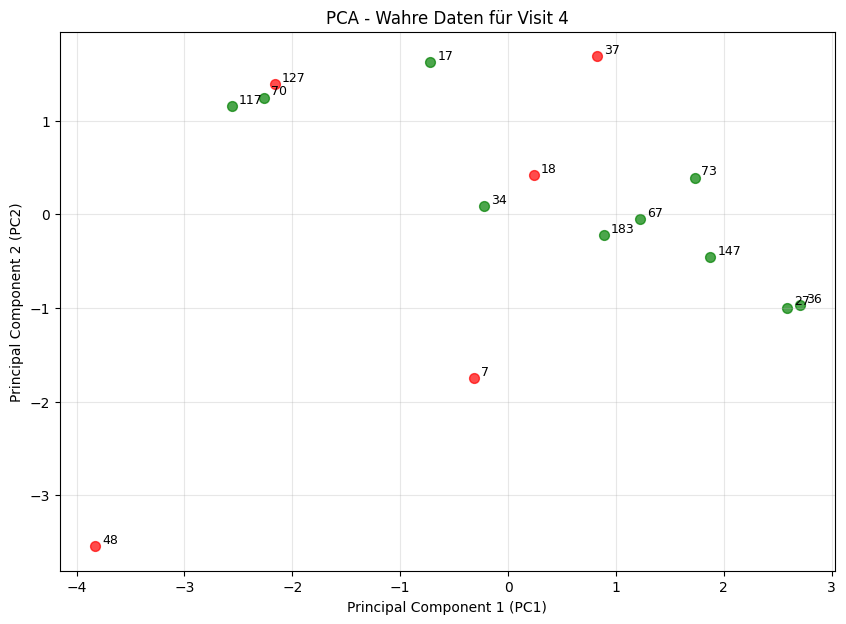

In [142]:
pca_results_plot(df_visit3_4,4)

In [143]:
df[df["Visit"] == 4]

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
12,OAS2_0007,OAS2_0007_MR4,Demented,4,1281,M,R,75,16,2.0,27.0,1.0,1372,0.710,1.279
31,OAS2_0017,OAS2_0017_MR4,Nondemented,4,1861,M,R,85,12,3.0,30.0,0.0,1820,0.755,0.964
35,OAS2_0018,OAS2_0018_MR4,Converted,4,1933,F,R,92,14,1.0,27.0,0.5,1423,0.696,1.234
50,OAS2_0027,OAS2_0027_MR4,Nondemented,4,1779,F,R,74,12,3.0,30.0,0.0,1353,0.772,1.297
65,OAS2_0034,OAS2_0034_MR4,Nondemented,4,1884,F,R,84,16,1.0,30.0,0.0,1453,0.684,1.208
70,OAS2_0036,OAS2_0036_MR4,Nondemented,4,1770,F,R,73,13,4.0,30.0,0.0,1360,0.773,1.291
75,OAS2_0037,OAS2_0037_MR4,Demented,4,2508,M,R,89,12,4.0,26.0,0.5,1485,0.706,1.181
100,OAS2_0048,OAS2_0048_MR4,Demented,4,970,M,R,68,16,1.0,7.0,1.0,1714,0.682,1.024
144,OAS2_0067,OAS2_0067_MR4,Nondemented,4,2163,M,R,73,12,4.0,28.0,0.0,1444,0.722,1.215
152,OAS2_0070,OAS2_0070_MR4,Nondemented,4,1870,M,R,85,17,1.0,30.0,0.0,1724,0.704,1.018
